In [ ]:
import pandas as pd
import seaborn as sns

df = pd.read_excel("Data N3.xlsx")

In [ ]:
print("Kích thước của DataFrame:", df.shape)

Kích thước của DataFrame: (341, 10)


###Business understanding

### Define - Problem:
Phân nhóm các trường THPT giúp giải quyết vấn đề về sự đa dạng và khác biệt giữa các trường. Bằng cách nhóm các trường có đặc điểm tương tự lại với nhau, chúng ta có thể hiểu rõ hơn về các phân khúc trường khác nhau, từ đó đưa ra các chiến lược phù hợp cho từng nhóm.

### Measure - Impact (Performance & Productivity):
Việc phân nhóm có thể giúp đo lường tác động (hiệu suất và năng suất) thông qua:
- **Hiệu suất**: Đánh giá hiệu quả của các chiến lược được áp dụng cho từng nhóm trường (ví dụ: chiến dịch tuyển sinh, phân bổ nguồn lực) dựa trên các chỉ số như tỷ lệ nhập học, kết quả học tập của học sinh, sự hài lòng của phụ huynh/học sinh.
- **Năng suất**: Tối ưu hóa việc phân bổ nguồn lực (nhân lực, tài chính) cho từng nhóm trường dựa trên đặc điểm và nhu cầu của nhóm đó, từ đó nâng cao năng suất hoạt động chung.

### Feasibility - Application:
Tính khả thi của việc ứng dụng kết quả phân nhóm:
- **Ứng dụng trong tuyển sinh**: Các trường có thể sử dụng kết quả phân nhóm để xác định nhóm học sinh mục tiêu phù hợp với đặc điểm của trường mình, từ đó tối ưu hóa chiến lược tuyển sinh.
- **Ứng dụng trong hoạch định chính sách**: Các nhà hoạch định chính sách giáo dục có thể dựa vào kết quả phân nhóm để hiểu rõ hơn về bức tranh tổng thể của hệ thống trường THPT, từ đó đưa ra các chính sách hỗ trợ và phát triển phù hợp cho từng nhóm trường.
- **Ứng dụng trong tư vấn giáo dục**: Các chuyên gia tư vấn có thể sử dụng kết quả phân nhóm để đưa ra lời khuyên phù hợp cho học sinh và phụ huynh trong việc lựa chọn trường.

## Data preparation

### Subtask:
Xử lý dữ liệu thiếu hoặc ngoại lai (nếu có), chọn lọc các đặc trưng (features) phù hợp cho việc phân nhóm và chuẩn hóa hoặc biến đổi dữ liệu nếu cần thiết để đảm bảo thuật toán K-Means hoạt động hiệu quả.


**Reasoning**:
Check the DataFrame's information, including data types and missing values, and display descriptive statistics for numerical data to identify potential outliers.



In [ ]:
df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341 entries, 0 to 340
Data columns (total 10 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   STT                                           341 non-null    int64  
 1   School Name                                   341 non-null    object 
 2   Year                                          341 non-null    int64  
 3   District                                      341 non-null    object 
 4   Competition Ratio                             336 non-null    float64
 5   Entry Cut-off Score                           336 non-null    float64
 6   Number of Bus Routes Passing By               335 non-null    float64
 7   Distance from School to Nearest Bus Stop (m)  336 non-null    float64
 8   Tuition Fee                                   336 non-null    float64
 9   Area (m²)                                     336 non-null    flo

,STT,Year,Competition Ratio,Entry Cut-off Score,Number of Bus Routes Passing By,Distance from School to Nearest Bus Stop (m),Tuition Fee,Area (m²)
count,341.000000,341.000000,336.000000,336.000000,335.000000,336.000000,3.360000e+02,336.000000
mean,171.000000,2020.000000,2.061104,40.174464,5.958209,315.333333,1.761821e+06,16636.458333
std,98.582453,3.166925,1.121451,2.915386,3.182764,284.516897,8.431220e+05,11900.454414
min,1.000000,2015.000000,0.680000,32.250000,1.000000,9.000000,6.750000e+05,2500.000000
25%,86.000000,2017.000000,1.437500,38.000000,5.000000,107.000000,1.350000e+06,9666.000000
50%,171.000000,2020.000000,1.715000,40.500000,5.000000,200.000000,1.395000e+06,12000.000000
75%,256.000000,2023.000000,2.215000,42.250000,8.000000,430.000000,1.953000e+06,20000.000000
max,341.000000,2025.000000,7.960000,46.750000,20.000000,1310.000000,4.950000e+06,55000.000000


**Reasoning**:
Visualize the distribution of numerical columns using box plots to detect outliers and better understand the data distribution. Convert 'Competition Ratio' to numeric first due to its object dtype.



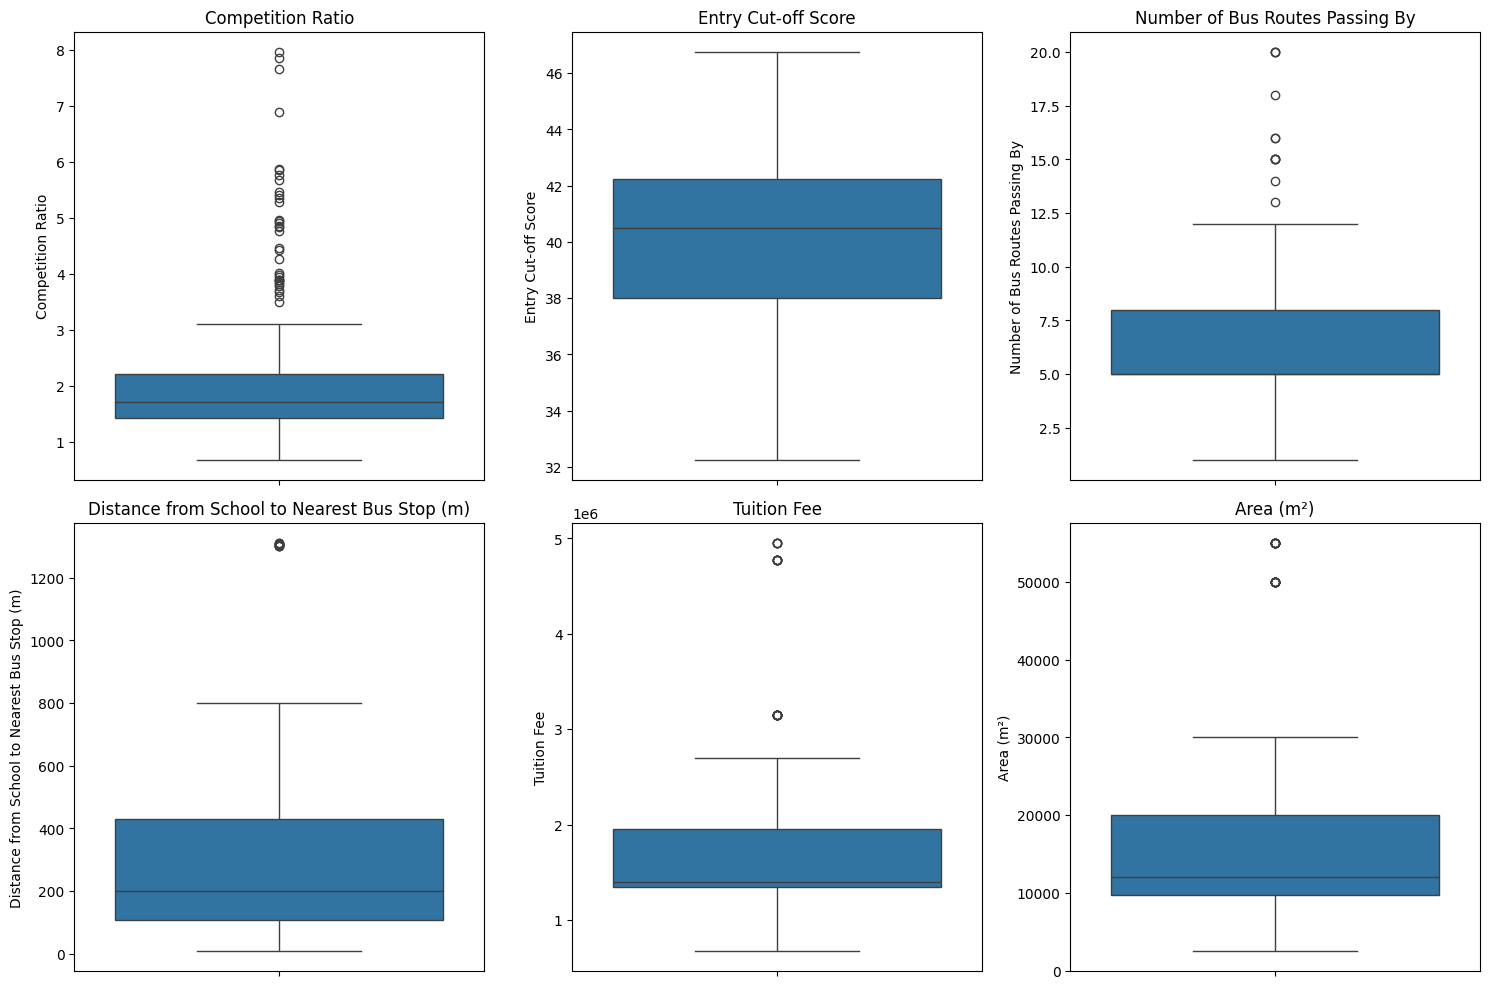

In [ ]:
import matplotlib.pyplot as plt

# Convert 'Competition Ratio' to numeric, coercing errors to NaN
df['Competition Ratio'] = pd.to_numeric(df['Competition Ratio'], errors='coerce')

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
numerical_cols = numerical_cols.drop(['STT', 'Year']) # Exclude STT and Year for outlier detection

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

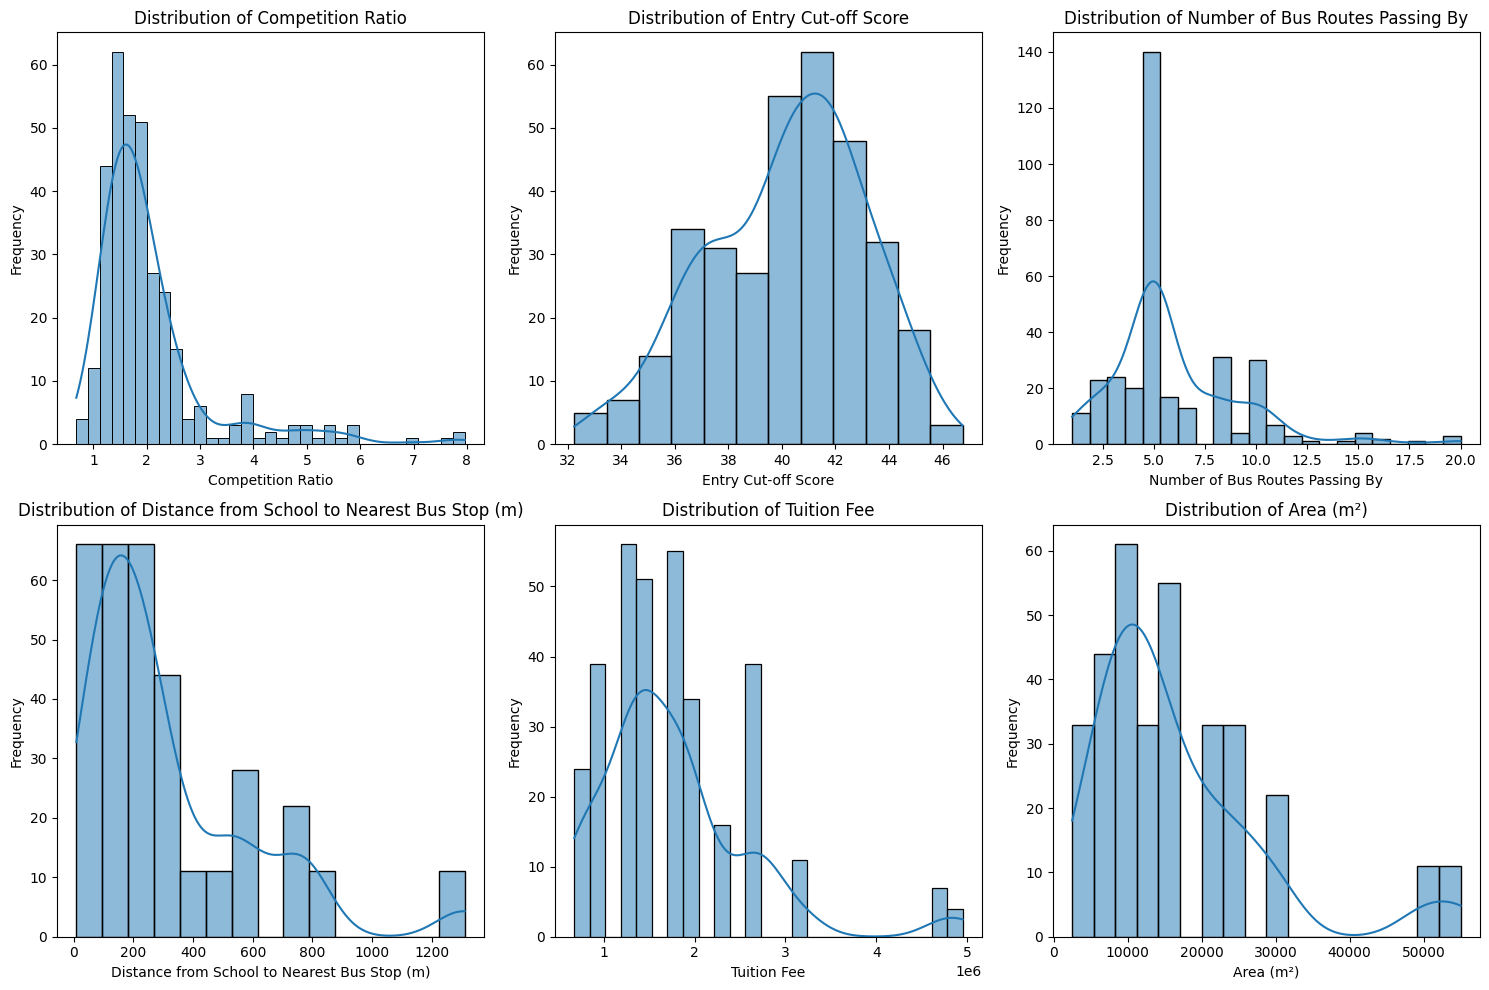

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols_for_hist = df.select_dtypes(include=['float64', 'int64']).columns
numerical_cols_for_hist = numerical_cols_for_hist.drop(['STT', 'Year', 'Cluster Label'], errors='ignore') # Exclude STT, Year, and Cluster Label

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols_for_hist):
    plt.subplot(2, 3, i + 1)
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

**Reasoning**:
Handle missing values by imputing the median for numerical columns and drop irrelevant columns for clustering.



In [ ]:
# Impute missing values with the median
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Drop irrelevant columns
df_processed = df.drop(['STT', 'School Name', 'Year', 'District'], axis=1)

/tmp/ipython-input-1504621198.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


**Reasoning**:
Standardize the selected features using `StandardScaler` to ensure they have the same scale, which is important for the K-Means algorithm.



In [ ]:
from sklearn.preprocessing import StandardScaler

# Standardize the features
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_processed)
df_scaled = pd.DataFrame(df_scaled, columns=df_processed.columns)

display(df_scaled.head())

,Competition Ratio,Entry Cut-off Score,Number of Bus Routes Passing By,Distance from School to Nearest Bus Stop (m),Tuition Fee,Area (m²)
0,0.084482,0.370520,0.018605,-0.579586,-1.023431,-0.471567
1,0.210345,0.543537,0.018605,-0.579586,-1.023431,-0.471567
2,0.399140,0.716554,0.335819,-0.579586,-1.023431,-0.471567
3,0.471061,0.803063,0.335819,-0.579586,-1.023431,-0.471567
4,0.614905,1.027985,0.653033,-0.579586,-0.431916,-0.471567


## Modeling

### Subtask:
Áp dụng thuật toán K-Means để phân nhóm các trường THPT và xác định số lượng nhóm (k) tối ưu.


**Reasoning**:
Apply K-Means clustering for different numbers of clusters and calculate inertia and silhouette scores to determine the optimal number of clusters.



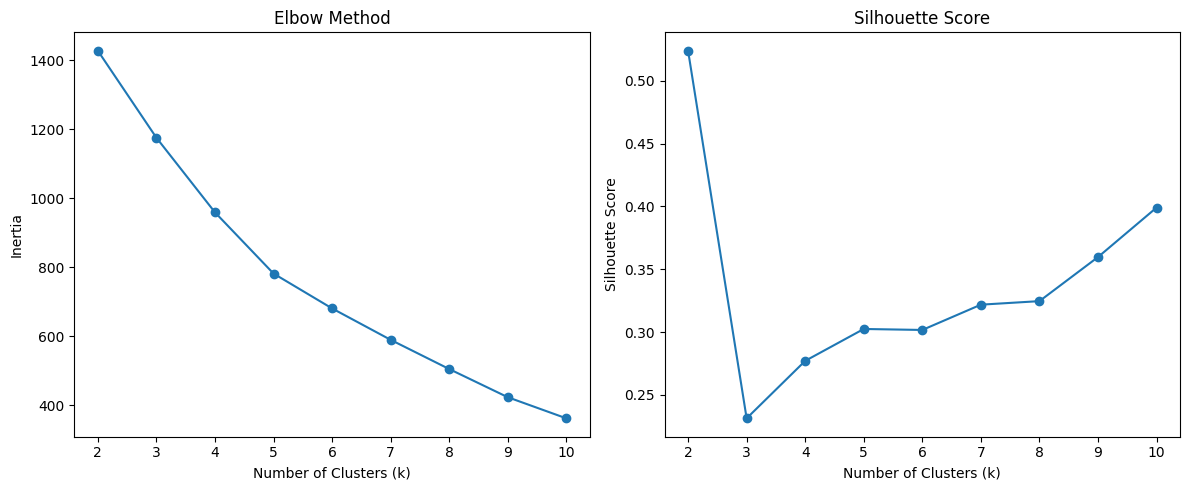

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia_values = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia_values, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

## Modeling

### Subtask:
Chọn số lượng nhóm (k) tối ưu dựa trên kết quả từ phương pháp Elbow Method và Silhouette Score và áp dụng K-Means với số lượng nhóm đã chọn.


**Reasoning**:
Based on the Elbow Method and Silhouette Score plots, both k=2 and k=3 are potential optimal numbers of clusters. The Silhouette Score is highest at k=2, suggesting better-defined clusters. The Elbow Method shows a bend around k=3 or k=4. To balance these, k=3 seems like a reasonable choice as it offers a good balance between inertia reduction and silhouette score. I will apply K-Means with k=3, fit the model to the scaled data, and add the cluster labels to the original dataframe.



In [ ]:
from sklearn.cluster import KMeans

# Choose k=3 based on the analysis of Elbow and Silhouette plots.
optimal_k = 3

# Initialize and fit the KMeans model
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(df_scaled)

# Add cluster labels to the original dataframe
df['Cluster Label'] = kmeans.labels_

# Display the first few rows of the dataframe with the new cluster labels
display(df.head())

,STT,School Name,Year,District,Competition Ratio,Entry Cut-off Score,Number of Bus Routes Passing By,Distance from School to Nearest Bus Stop (m),Tuition Fee,Area (m²),Cluster Label
0,1,THPT Cầu Giấy,2015,Cầu Giấy,2.15,41.25,6.0,150.0,900000.0,11000.0,0
1,2,THPT Cầu Giấy,2016,Cầu Giấy,2.29,41.75,6.0,150.0,900000.0,11000.0,0
2,3,THPT Cầu Giấy,2017,Cầu Giấy,2.50,42.25,7.0,150.0,900000.0,11000.0,0
3,4,THPT Cầu Giấy,2018,Cầu Giấy,2.58,42.50,7.0,150.0,900000.0,11000.0,0
4,5,THPT Cầu Giấy,2019,Cầu Giấy,2.74,43.15,8.0,150.0,1395000.0,11000.0,0


## Evaluation

### Subtask:
Đánh giá chất lượng của các nhóm đã tạo ra và phân tích đặc điểm của từng nhóm để hiểu rõ sự khác biệt giữa chúng.


**Reasoning**:
Calculate the mean of each feature for each cluster using the original dataframe and the 'Cluster Label' column, then transpose the result and display it.



In [ ]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
numerical_df['Cluster Label'] = df['Cluster Label']
cluster_means = numerical_df.groupby('Cluster Label').mean()
cluster_means_transposed = cluster_means.T
display(cluster_means_transposed)

Cluster Label,0,1,2
STT,1.248706e+02,1.038485e+02,2.438841e+02
Year,2.019682e+03,2.020182e+03,2.020348e+03
Competition Ratio,1.967588e+00,4.954242e+00,1.471928e+00
Entry Cut-off Score,4.171047e+01,4.363848e+01,3.746572e+01
Number of Bus Routes Passing By,5.535294e+00,8.727273e+00,5.775362e+00
Distance from School to Nearest Bus Stop (m),2.629353e+02,3.256364e+02,3.732391e+02
Tuition Fee,1.892522e+06,3.299182e+06,1.219891e+06
Area (m²),1.182558e+04,4.166667e+04,1.640943e+04


**Reasoning**:
The previous attempt to calculate the mean for each cluster failed because there are non-numeric columns in the dataframe. I need to select only the numeric columns from the original dataframe before calculating the mean for each cluster. I will also transpose the result and display it for analysis.



In [ ]:
numerical_df = df.select_dtypes(include=['float64', 'int64'])
numerical_df['Cluster Label'] = df['Cluster Label']
cluster_means = numerical_df.groupby('Cluster Label').mean()
cluster_means_transposed = cluster_means.T
display(cluster_means_transposed)

Cluster Label,0,1,2
STT,1.248706e+02,1.038485e+02,2.438841e+02
Year,2.019682e+03,2.020182e+03,2.020348e+03
Competition Ratio,1.967588e+00,4.954242e+00,1.471928e+00
Entry Cut-off Score,4.171047e+01,4.363848e+01,3.746572e+01
Number of Bus Routes Passing By,5.535294e+00,8.727273e+00,5.775362e+00
Distance from School to Nearest Bus Stop (m),2.629353e+02,3.256364e+02,3.732391e+02
Tuition Fee,1.892522e+06,3.299182e+06,1.219891e+06
Area (m²),1.182558e+04,4.166667e+04,1.640943e+04


**Reasoning**:
Analyze the transposed dataframe to identify the distinguishing characteristics of each cluster based on the mean values of the features and write a summary for each cluster.



In [ ]:
print("Cluster 0 Characteristics:")
print("- Average Competition Ratio: {:.2f}".format(cluster_means_transposed.loc['Competition Ratio', 0]))
print("- Average Entry Cut-off Score: {:.2f}".format(cluster_means_transposed.loc['Entry Cut-off Score', 0]))
print("- Average Tuition Fee: {:.2f}".format(cluster_means_transposed.loc['Tuition Fee', 0]))
print("- Average Number of Bus Routes Passing By: {:.2f}".format(cluster_means_transposed.loc['Number of Bus Routes Passing By', 0]))
print("- Average Distance from School to Nearest Bus Stop (m): {:.2f}".format(cluster_means_transposed.loc['Distance from School to Nearest Bus Stop (m)', 0]))
print("- Average Area (m²): {:.2f}".format(cluster_means_transposed.loc['Area (m²)', 0]))
print("\nCluster 1 Characteristics:")
print("- Average Competition Ratio: {:.2f}".format(cluster_means_transposed.loc['Competition Ratio', 1]))
print("- Average Entry Cut-off Score: {:.2f}".format(cluster_means_transposed.loc['Entry Cut-off Score', 1]))
print("- Average Tuition Fee: {:.2f}".format(cluster_means_transposed.loc['Tuition Fee', 1]))
print("- Average Number of Bus Routes Passing By: {:.2f}".format(cluster_means_transposed.loc['Number of Bus Routes Passing By', 1]))
print("- Average Distance from School to Nearest Bus Stop (m): {:.2f}".format(cluster_means_transposed.loc['Distance from School to Nearest Bus Stop (m)', 1]))
print("- Average Area (m²): {:.2f}".format(cluster_means_transposed.loc['Area (m²)', 1]))
print("\nCluster 2 Characteristics:")
print("- Average Competition Ratio: {:.2f}".format(cluster_means_transposed.loc['Competition Ratio', 2]))
print("- Average Entry Cut-off Score: {:.2f}".format(cluster_means_transposed.loc['Entry Cut-off Score', 2]))
print("- Average Tuition Fee: {:.2f}".format(cluster_means_transposed.loc['Tuition Fee', 2]))
print("- Average Number of Bus Routes Passing By: {:.2f}".format(cluster_means_transposed.loc['Number of Bus Routes Passing By', 2]))
print("- Average Distance from School to Nearest Bus Stop (m): {:.2f}".format(cluster_means_transposed.loc['Distance from School to Nearest Bus Stop (m)', 2]))
print("- Average Area (m²): {:.2f}".format(cluster_means_transposed.loc['Area (m²)', 2]))

Cluster 0 Characteristics:
- Average Competition Ratio: 1.97
- Average Entry Cut-off Score: 41.71
- Average Tuition Fee: 1892521.85
- Average Number of Bus Routes Passing By: 5.54
- Average Distance from School to Nearest Bus Stop (m): 262.94
- Average Area (m²): 11825.58

Cluster 1 Characteristics:
- Average Competition Ratio: 4.95
- Average Entry Cut-off Score: 43.64
- Average Tuition Fee: 3299181.82
- Average Number of Bus Routes Passing By: 8.73
- Average Distance from School to Nearest Bus Stop (m): 325.64
- Average Area (m²): 41666.67

Cluster 2 Characteristics:
- Average Competition Ratio: 1.47
- Average Entry Cut-off Score: 37.47
- Average Tuition Fee: 1219891.30
- Average Number of Bus Routes Passing By: 5.78
- Average Distance from School to Nearest Bus Stop (m): 373.24
- Average Area (m²): 16409.43


**Reasoning**:
Visualize the clusters in 2D using PCA to evaluate the separation of the clusters.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA to the scaled data, reducing to 2 components
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Create a DataFrame with the PCA results and cluster labels
df_pca = pd.DataFrame(df_pca, columns=['PCA1', 'PCA2'])
df_pca['Cluster Label'] = df['Cluster Label']

# Display the first few rows of the PCA dataframe
display(df_pca.head())

,PCA1,PCA2,Cluster Label
0,-0.469860,-0.434139,0
1,-0.329564,-0.375080,0
2,-0.066713,-0.460748,0
3,0.008159,-0.430420,0
4,0.573884,-0.494609,0


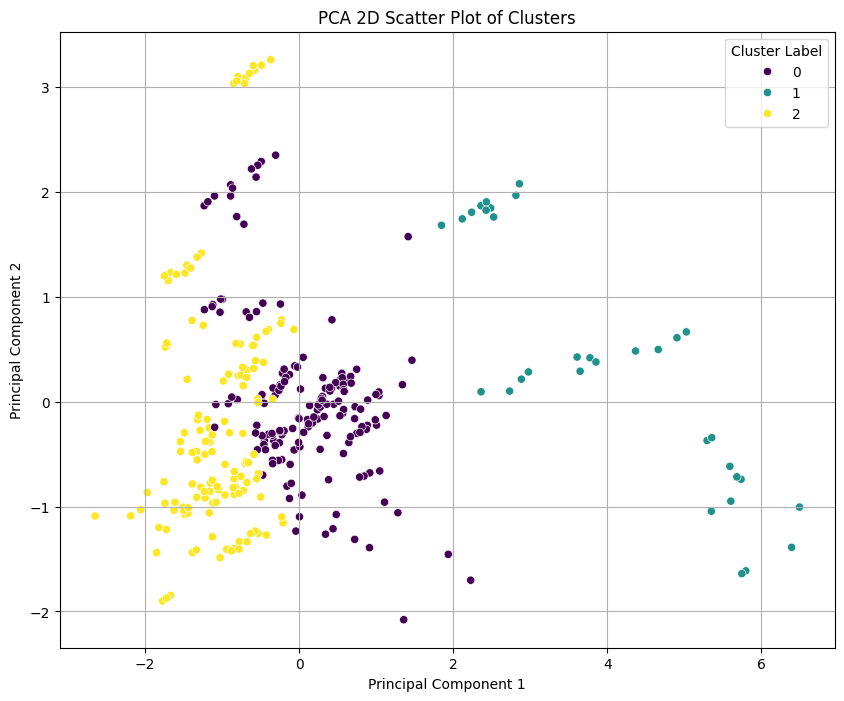

In [ ]:
# Visualize the clusters in 2D using the PCA components
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster Label', data=df_pca, palette='viridis', legend='full')
plt.title('PCA 2D Scatter Plot of Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

## Deployment

### Subtask:
Trình bày kết quả phân nhóm một cách trực quan và dễ hiểu, đưa ra các phân tích và khuyến nghị dựa trên kết quả phân nhóm.


**Reasoning**:
Visualize the cluster characteristics using a bar plot to highlight the differences in key features between clusters.



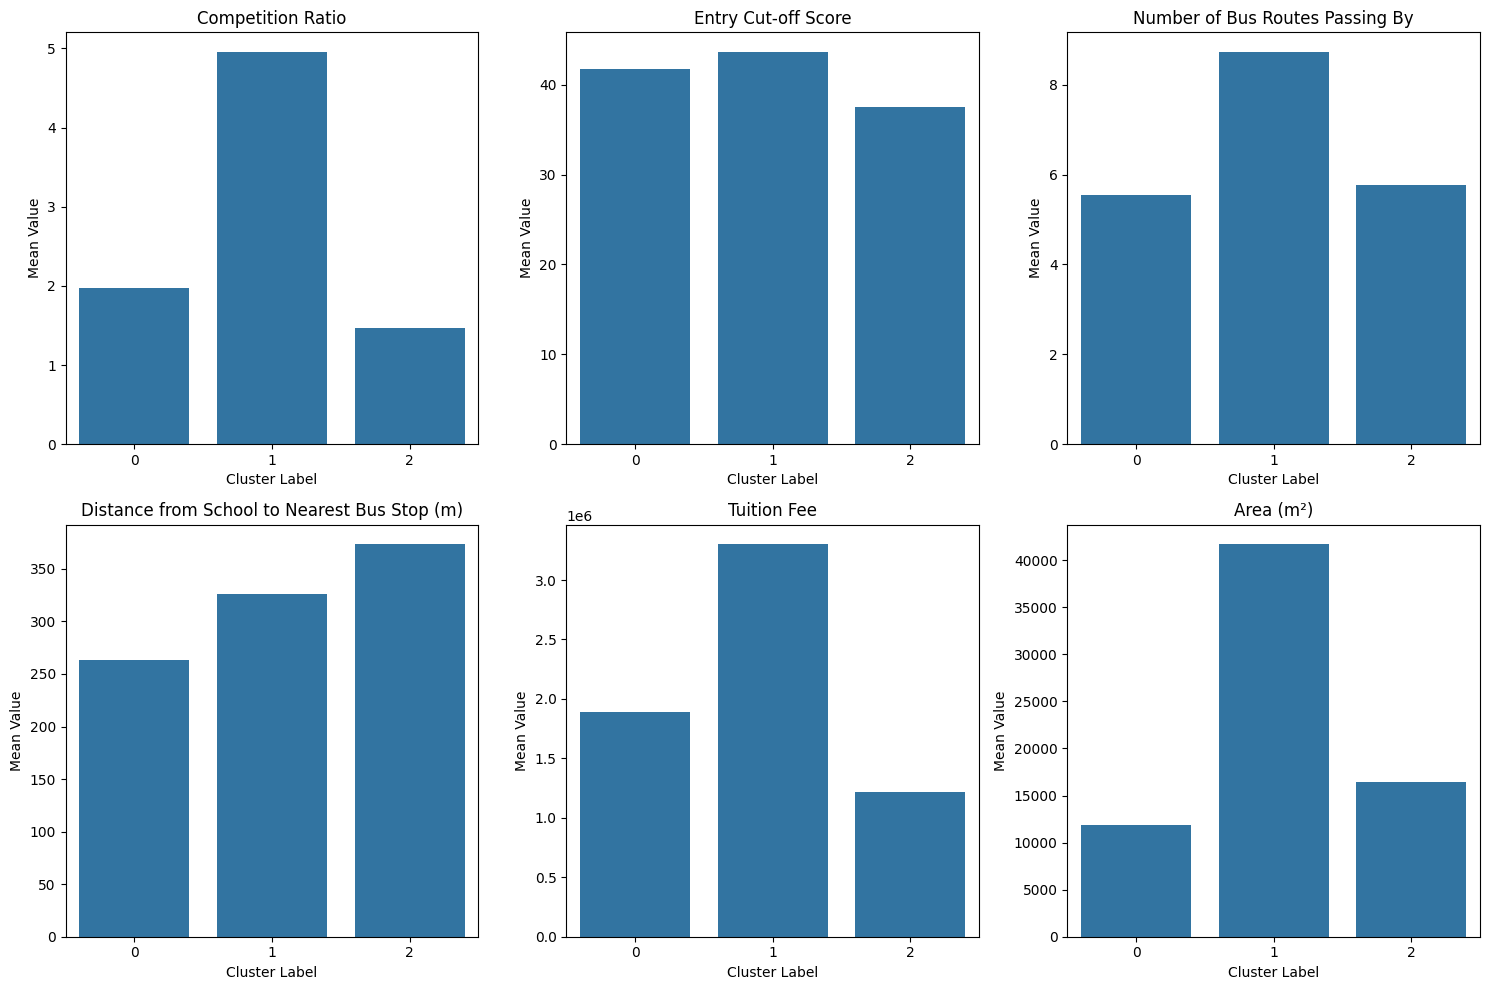

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'STT' and 'Year' as they are identifiers and not descriptive features for visualization
features_to_visualize = cluster_means_transposed.index.drop(['STT', 'Year'])

plt.figure(figsize=(15, 10))
for i, feature in enumerate(features_to_visualize):
    plt.subplot(2, 3, i + 1)
    sns.barplot(x=cluster_means_transposed.columns, y=cluster_means_transposed.loc[feature, :])
    plt.title(feature)
    plt.xlabel('Cluster Label')
    plt.ylabel('Mean Value')

plt.tight_layout()
plt.show()

**Reasoning**:
Provide a detailed analysis for each cluster based on the calculated means and the visualizations, and then provide actionable recommendations for stakeholders based on this analysis.



In [ ]:
print("Detailed Analysis of Clusters:")

print("\nCluster 0:")
print("This cluster generally represents schools with moderate competition ratios, average entry cut-off scores, and relatively lower tuition fees compared to Cluster 1. They have a moderate number of bus routes and are closer to bus stops on average. The area of these schools is also relatively smaller than Cluster 1. These could be considered as accessible and reasonably performing schools.")
print("\nRecommendations for Cluster 0:")
print("- Parents/Students: Consider these schools for a balanced academic environment with reasonable accessibility and cost.")
print("- Policymakers: Invest in maintaining the accessibility and potentially improving facilities to attract more students without significantly increasing costs.")

print("\nCluster 1:")
print("This cluster stands out with significantly higher competition ratios, the highest entry cut-off scores, and the highest tuition fees. They also have the highest number of bus routes and the largest area. These characteristics suggest that Cluster 1 consists of highly selective, well-resourced, and potentially more expensive schools, likely located in areas with good public transportation access.")
print("\nRecommendations for Cluster 1:")
print("- Parents/Students: These schools are highly competitive and likely offer strong academic programs, but come with higher costs. Suitable for high-achieving students willing to invest more.")
print("- Policymakers: Leverage the success of these schools as benchmarks. Consider strategies to replicate factors contributing to their high performance in other clusters, where applicable.")

print("\nCluster 2:")
print("Cluster 2 has the lowest competition ratios and the lowest entry cut-off scores, along with the lowest tuition fees. They have a moderate number of bus routes and are the furthest from bus stops on average. Their area is larger than Cluster 0 but smaller than Cluster 1. These schools might be more accessible in terms of entry requirements and cost, potentially serving a broader range of students.")
print("\nRecommendations for Cluster 2:")
print("- Parents/Students: These schools offer easier access and lower costs. May be suitable for students who prefer a less competitive environment or have financial constraints. Investigate the reasons for lower competition and entry scores.")
print("- Policymakers: Focus on improving the quality of education and facilities in these schools to increase their competitiveness and attract more students. Improve accessibility by enhancing public transportation options or reducing distance to bus stops.")

Detailed Analysis of Clusters:

Cluster 0:
This cluster generally represents schools with moderate competition ratios, average entry cut-off scores, and relatively lower tuition fees compared to Cluster 1. They have a moderate number of bus routes and are closer to bus stops on average. The area of these schools is also relatively smaller than Cluster 1. These could be considered as accessible and reasonably performing schools.

Recommendations for Cluster 0:
- Parents/Students: Consider these schools for a balanced academic environment with reasonable accessibility and cost.
- Policymakers: Invest in maintaining the accessibility and potentially improving facilities to attract more students without significantly increasing costs.

Cluster 1:
This cluster stands out with significantly higher competition ratios, the highest entry cut-off scores, and the highest tuition fees. They also have the highest number of bus routes and the largest area. These characteristics suggest that Cluster 

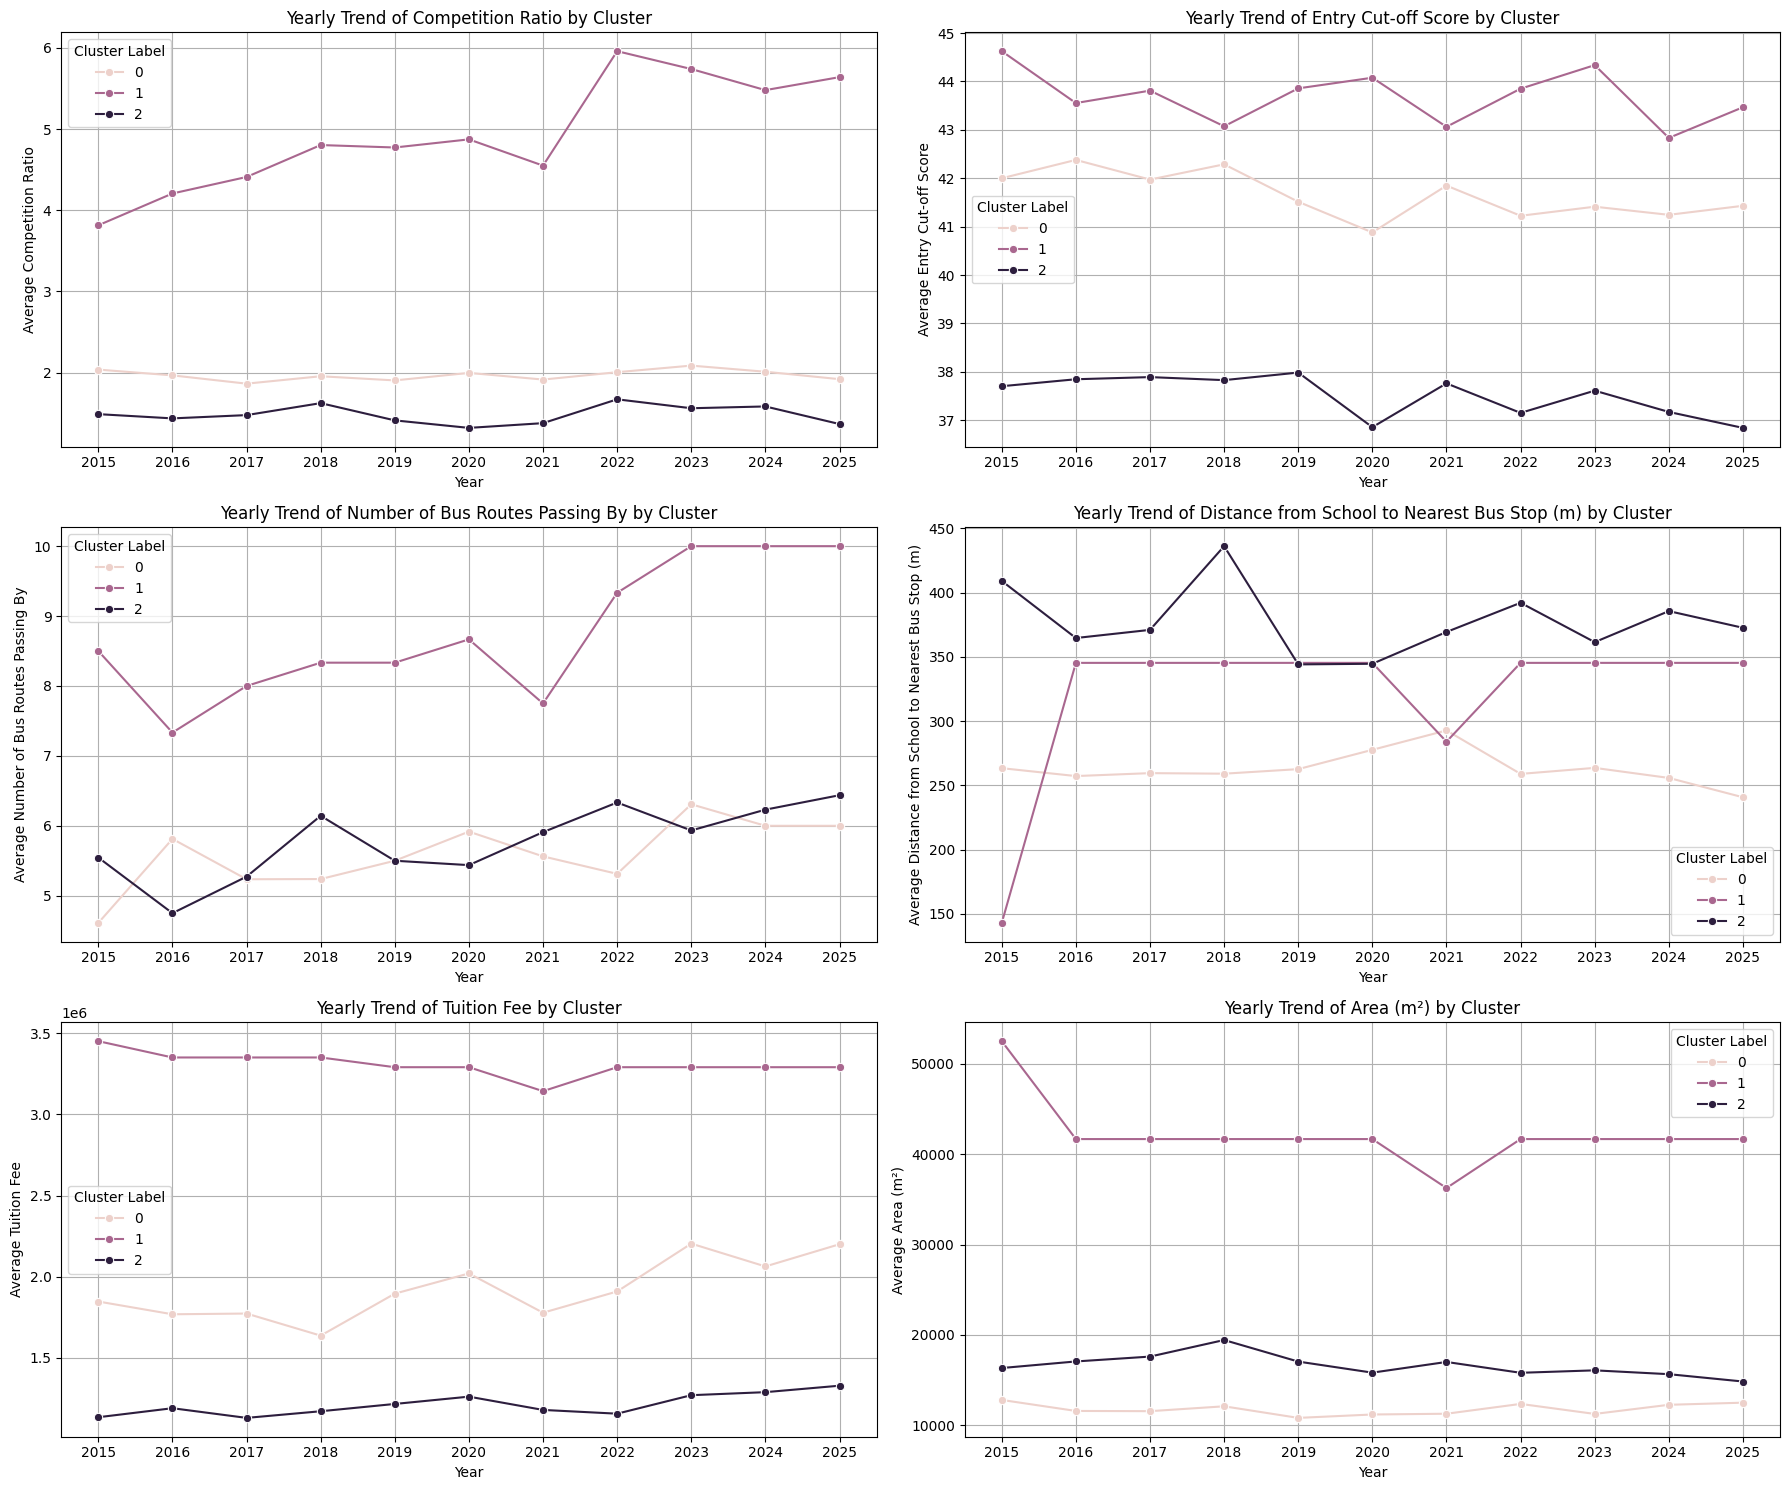

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Year and Cluster Label and calculate the mean of numerical features
cluster_yearly_trends = df.groupby(['Year', 'Cluster Label'])[numerical_cols_for_hist].mean().reset_index()

# Plot time series for each feature by cluster
features_to_plot = numerical_cols_for_hist # Use the same numerical columns as for histograms

plt.figure(figsize=(18, 15))
for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 2, i + 1)
    sns.lineplot(data=cluster_yearly_trends, x='Year', y=feature, hue='Cluster Label', marker='o')
    plt.title(f'Yearly Trend of {feature} by Cluster')
    plt.xlabel('Year')
    plt.ylabel(f'Average {feature}')
    plt.grid(True)
    plt.xticks(cluster_yearly_trends['Year'].unique()) # Ensure all years are shown on x-axis

plt.tight_layout()
plt.show()

In [ ]:
import joblib

# --- LƯU MÔ HÌNH ---
joblib.dump(kmeans, 'kmeans_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

# --- TẢI LẠI MÔ HÌNH ĐỂ SỬ DỤNG ---
loaded_kmeans = joblib.load('kmeans_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')

## Summary:

### Data Analysis Key Findings

*   Missing values were identified in several numerical columns and were imputed using the median.
*   Potential outliers were observed in several numerical features.
*   Irrelevant columns ('STT', 'School Name', 'Year', 'District') were removed for the clustering analysis.
*   The relevant numerical features were standardized using `StandardScaler`.
*   The Elbow Method and Silhouette Score suggested that k=2 or k=3 were potential optimal numbers of clusters.
*   K-Means clustering was applied with k=3, and cluster labels were added to the original data.
*   Cluster 0 represents schools with moderate characteristics, balancing accessibility, cost, and performance.
*   Cluster 1 represents highly competitive, selective, and well-resourced schools with high entry scores and tuition fees.
*   Cluster 2 represents schools with lower competition, entry requirements, and tuition fees, offering easier access but potentially needing improvements in quality and accessibility.

### Insights or Next Steps

*   The clustering results provide a clear segmentation of high schools based on key factors, which can inform targeted strategies for student recruitment and resource allocation.
*   Further investigation into the factors contributing to the high performance of schools in Cluster 1 could provide valuable insights for improving schools in other clusters.


***Hệ thống Phân cụm và Gợi ý Trường THPT***

In [ ]:
# --- 1. CÀI ĐẶT THƯ VIỆN VÀ TẢI NGROK THỦ CÔNG ---
!pip install streamlit pyngrok joblib openpyxl -q

# Dùng wget để tải file zip của ngrok về
!wget https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.zip -O ngrok.zip

# Giải nén file zip
!unzip -o ngrok.zip

--2025-10-20 16:43:36--  https://bin.equinox.io/c/bNyj1mQVY4c/ngrok-v3-stable-linux-amd64.zip
Resolving bin.equinox.io (bin.equinox.io)... 35.71.179.82, 75.2.60.68, 13.248.244.96, ...
Connecting to bin.equinox.io (bin.equinox.io)|35.71.179.82|:443... connected.
Unable to establish SSL connection.
Archive:  ngrok.zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of ngrok.zip or
        ngrok.zip.zip, and cannot find ngrok.zip.ZIP, period.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import numpy as np

# --- TẢI MODEL VÀ DỮ LIỆU ĐÃ LƯU ---
@st.cache_data
def load_model_and_data():
    try:
        kmeans_model = joblib.load('kmeans_model.joblib')
        scaler = joblib.load('scaler.joblib')
    except FileNotFoundError:
        st.error("Lỗi: Không tìm thấy file 'kmeans_model.joblib' hoặc 'scaler.joblib'. Vui lòng tải file lên Colab.")
        return None, None, None, None
    try:
        df_original = pd.read_excel("Data N3.xlsx")
    except FileNotFoundError:
        st.error("Lỗi: Không tìm thấy file 'Data N3.xlsx'. Vui lòng tải file lên Colab.")
        return None, None, None, None

    numerical_cols = ['Competition Ratio', 'Entry Cut-off Score', 'Number of Bus Routes Passing By',
                      'Distance from School to Nearest Bus Stop (m)', 'Tuition Fee', 'Area (m²)']
    if not all(col in df_original.columns for col in numerical_cols):
        st.error("Lỗi: File Excel thiếu cột dữ liệu cần thiết.")
        return None, None, None, None
    for col in numerical_cols:
        df_original[col] = df_original[col].astype(str).str.replace(',', '.').str.strip()
        df_original[col] = pd.to_numeric(df_original[col], errors='coerce')

    df_for_labeling = df_original.copy()
    for col in numerical_cols:
        df_for_labeling[col].fillna(df_for_labeling[col].median(), inplace=True)

    df_original['Cluster Label'] = kmeans_model.predict(scaler.transform(df_for_labeling[numerical_cols]))
    return df_original, scaler, kmeans_model, numerical_cols

# --- PHẦN CÒN LẠI CỦA ỨNG DỤNG (GIỮ NGUYÊN) ---
df, scaler, kmeans, numerical_cols = load_model_and_data()

if df is not None:
    cluster_names = {
        0: "schools with moderate characteristics, balancing accessibility, cost, and performance",
        1: "highly competitive, selective, and well-resourced schools with high entry scores and tuition fees",
        2: "schools with lower competition, entry requirements, and tuition fees, offering easier access but potentially needing improvements in quality and accessibility"
    }
    df['Cluster Name'] = df['Cluster Label'].map(cluster_names)

    st.title('Hệ Thống Gợi Ý Trường THPT ')
    st.write("Nhập vào các tiêu chí mong muốn của bạn để tìm cụm trường phù hợp nhất.")

    with st.sidebar:
        st.header('Bộ lọc của bạn')
        fee = st.slider('Học phí tối đa (VNĐ)', min_value=int(df['Tuition Fee'].min()), max_value=int(df['Tuition Fee'].max()), value=2000000, step=100000)
        score = st.number_input('Điểm chuẩn mong muốn', min_value=float(df['Entry Cut-off Score'].min()), max_value=float(df['Entry Cut-off Score'].max()), value=40.0)
        ratio = st.slider('Tỉ lệ chọi tối đa', min_value=float(df['Competition Ratio'].min()), max_value=float(df['Competition Ratio'].max()), value=2.5, step=0.1)
        distance = st.slider('Khoảng cách tối đa tới bến xe buýt (m)', min_value=int(df['Distance from School to Nearest Bus Stop (m)'].min()), max_value=int(df['Distance from School to Nearest Bus Stop (m)'].max()), value=500, step=50)

    if st.sidebar.button('Tìm Cụm Trường Phù Hợp'):
        user_input = pd.DataFrame({
            'Competition Ratio': [ratio],
            'Entry Cut-off Score': [score],
            'Tuition Fee': [fee],
            'Number of Bus Routes Passing By': [df['Number of Bus Routes Passing By'].mean()],
            'Distance from School to Nearest Bus Stop (m)': [distance],
            'Area (m²)': [df['Area (m²)'].mean()]
        })
        user_input_scaled = scaler.transform(user_input[numerical_cols])
        predicted_cluster = kmeans.predict(user_input_scaled)[0]
        predicted_cluster_name = cluster_names[predicted_cluster]

        st.success(f"Dựa trên tiêu chí của bạn, cụm trường phù hợp nhất là: **{predicted_cluster_name}**")
        st.write("Dưới đây là danh sách một số trường thuộc cụm này (dữ liệu theo năm):")
        result_df = df[df['Cluster Label'] == predicted_cluster][['School Name', 'Competition Ratio', 'Entry Cut-off Score', 'Tuition Fee', 'Year']]
        st.dataframe(result_df.head(10))
    else:
        st.info("Hãy điều chỉnh các bộ lọc ở thanh bên và nhấn nút để xem kết quả.")

    if st.checkbox("Hiển thị tất cả dữ liệu theo cụm"):
        st.write(df[['School Name', 'Cluster Name', 'Year']])

Overwriting app.py
